# EVASPA Evaporative Fraction model and configuration

In [1]:
from __future__ import annotations

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import xarray as xr

In [4]:
from evaspa.ef import EFModel, initialize, run

### Generate test data 

In [5]:
def setup_data(
    dry: tuple[float, float],
    wet: tuple[float, float],
    albedo: tuple[float, float],
    valid: tuple[float, float] = (0.0, 1.0),
    fcover: tuple[float, float] | None = None,
    size: int = 125,
    seed: int = 0,
) -> xr.Dataset:
    """
    Generate data for tests
    """

    def dry_edge(v: npt.ArrayLike) -> npt.NDArray:
        return dry[1] * v + dry[0]

    def wet_edge(v: npt.ArrayLike) -> npt.NDArray:
        return wet[1] * v + wet[0]

    np.random.seed(seed)
    lon = np.linspace(start=1.0, stop=2.0, num=size, dtype=np.float32)
    lat = np.linspace(start=43.0, stop=44.0, num=size, dtype=np.float32)
    valid_arr = np.random.choice(
        [0, 1], size=(size, size), p=[valid[0], valid[1]]
    )
    albedo_arr = np.random.uniform(
        low=albedo[0], high=albedo[1], size=(size, size)
    )
    lst_func = np.vectorize(
        lambda x: np.random.uniform(wet_edge(x), dry_edge(x))
    )
    lst_arr = lst_func(albedo_arr)
    if fcover is not None:
        fcover_arr = np.random.uniform(
            low=fcover[0], high=fcover[1], size=(size, size)
        )
        lst_func = np.vectorize(
            lambda x, y: np.random.uniform(
                max(wet_edge(x), wet_edge(y)), min(dry_edge(x), dry_edge(y))
            )
        )
        lst_arr = lst_func(fcover_arr, albedo_arr)
    ef_albedo_arr = (dry_edge(albedo_arr) - lst_arr) / (
        dry_edge(albedo_arr) - wet_edge(albedo_arr)
    )
    data_vars = {
        "albedo": (["lon", "lat"], albedo_arr),
        "lst": (["lon", "lat"], lst_arr),
        "valid": (["lon", "lat"], valid_arr),
        "ef_albedo": (["lon", "lat"], ef_albedo_arr),
    }
    if fcover is not None:
        ef_fcover_arr = (dry_edge(fcover_arr) - lst_arr) / (
            dry_edge(fcover_arr) - wet_edge(fcover_arr)
        )
        data_vars["fcover"] = (["lon", "lat"], fcover_arr)
        data_vars["ef_fcover"] = (["lon", "lat"], ef_fcover_arr)
    return xr.Dataset(
        data_vars=data_vars,
        coords={
            "lon": ("lon", lon),
            "lat": ("lat", lat),
        },
        attrs={"description": "Test data"},
    )

In [6]:
# Generate data
data = setup_data(
    albedo=(0.0, 0.6),
    fcover=(0.0, 1.0),
    dry=(330.0, -10.0),
    wet=(300.0, 15.0),
    valid=(0.2, 0.8),
)

In [7]:
data

<xarray.Dataset> Size: 751kB
Dimensions:    (lon: 125, lat: 125)
Coordinates:
  * lon        (lon) float32 500B 1.0 1.008 1.016 1.024 ... 1.984 1.992 2.0
  * lat        (lat) float32 500B 43.0 43.01 43.02 43.02 ... 43.98 43.99 44.0
Data variables:
    albedo     (lon, lat) float64 125kB 0.2484 0.5421 0.05975 ... 0.3698 0.05055
    lst        (lon, lat) float64 125kB 320.4 314.4 321.7 ... 312.8 308.8 310.1
    valid      (lon, lat) int64 125kB 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 0 1 1
    ef_albedo  (lon, lat) float64 125kB 0.2982 0.6211 0.2689 ... 0.8448 0.6735
    fcover     (lon, lat) float64 125kB 0.8936 0.5573 0.2728 ... 0.4004 0.6618
    ef_fcover  (lon, lat) float64 125kB 0.08386 0.6263 0.2388 ... 0.8618 0.9843
Attributes:
    description:  Test data

In [8]:
def plot(
    data: xr.Dataset,
    var_name: str | None = None,
    model: EFModel | None = None,
    save: bool = False,
):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    if var_name is None and model is None:
        msg = "Provide either var_name or model"
        raise ValueError(msg)
    lst = data["lst"].data

    if var_name is not None:
        var = data[var_name].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    elif model is not None:
        var_name = model.var
        var = data[model.var].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel(var_name)
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()

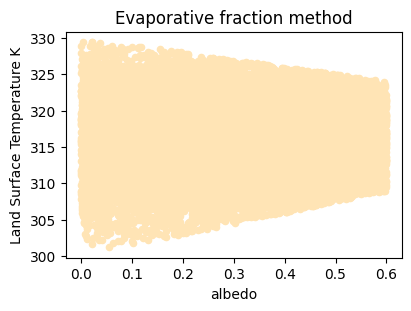

In [9]:
plot(data, "albedo")

## Configuration definition

In [10]:
config = {
    "models": [
        {
            "name": "model1",
            "dry_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "size",
                    "interval_nb": 20,
                    "percentile": [98, 100],
                    "selection": "median",
                },
            },
            "wet_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "size",
                    "interval_nb": 20,
                    "percentile": [0, 2],
                    "selection": "median",
                },
            },
            "var": "fcover",
        },
        {
            "name": "model2",
            "dry_edge": {
                "type": "LinearEdge",
                "config": {
                    "interval_type": "density",
                    "interval_nb": 20,
                    "percentile": [95, 100],
                    "selection": "median",
                },
            },
            "wet_edge": {
                "type": "FlatEdge",
                "config": {"selection": "min"},
            },
            "var": "albedo",
        },
    ],
    "options": {
        "selection": False,
        "merging": "mean",
    },
}

In [11]:
pprint(config, sort_dicts=False)

{'models': [{'name': 'model1',
             'dry_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'size',
                                     'interval_nb': 20,
                                     'percentile': [98, 100],
                                     'selection': 'median'}},
             'wet_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'size',
                                     'interval_nb': 20,
                                     'percentile': [0, 2],
                                     'selection': 'median'}},
             'var': 'fcover'},
            {'name': 'model2',
             'dry_edge': {'type': 'LinearEdge',
                          'config': {'interval_type': 'density',
                                     'interval_nb': 20,
                                     'percentile': [95, 100],
                                     'selection': 'median'}},
             'wet_edge': {'type': 'Fl

In [12]:
models, options = initialize(config)

In [ ]:
ef, ef_inst = run(models, data, **options)

In [14]:
ef

<xarray.Dataset> Size: 251kB
Dimensions:  (lon: 125, lat: 125)
Coordinates:
  * lon      (lon) float32 500B 1.0 1.008 1.016 1.024 ... 1.976 1.984 1.992 2.0
  * lat      (lat) float32 500B 43.0 43.01 43.02 43.02 ... 43.98 43.99 44.0
Data variables:
    model1   (lon, lat) float64 125kB 0.0942 0.6347 0.2258 ... 0.8895 0.9984
    model2   (lon, lat) float64 125kB 0.211 0.4214 0.1912 ... 0.6801 0.6481

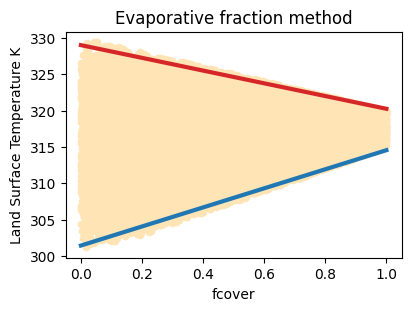

In [15]:
plot(data, model=EFModel.create(ef["model1"].attrs))

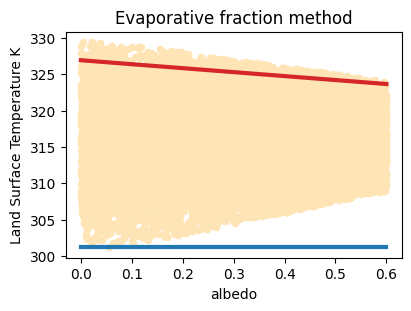

In [16]:
plot(data, model=EFModel.create(ef["model2"].attrs))